# Setup

![DDI_LM.png](DDI_LM.png)

# Experiments

In [22]:
import os
import warnings
import logging
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import precision_recall_curve, roc_curve


# Set thread limits before PyTorch import
os.environ.update({k: '1' for k in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS']})
import torch

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import Config, LossType
from report_utils import plot_experiment_results, find_balanced_threshold, render_interactive_visualization

warnings.simplefilter(action="ignore", category=FutureWarning)
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style('whitegrid')
sns.set_context('talk')



In [36]:

def get_base_config():
    """Returns a fresh base configuration for experiments to prevent cross-contamination."""
    config = Config()
    config.training.seed = 42
    config.graph.seed_graph_sampling = 42
    config.graph.current_graph = "DrugBank_CRESCENDDI"
    config.run.take_negative_samples = True
    config.training.repetitions = 1
    config.graph.feature = "DESC_GPT"
    return config

def get_feature_experiment_config():
    """Returns the configuration for the feature embeddings experiment."""
    config = get_base_config()
    config.run.loss_type = LossType.WeightedBCEWithLogitsLoss
    config.run.pos_loss_multiplier = 0.5
    config.run.upsample_negative_labels = False
    config.run.use_only_sampled_negatives_in_train = False
    return config


## Experiments on Loss Functions and Labels

This section describes how negative examples are constructed for training and the loss configurations evaluated.

Negatives for training

- Sampled negatives: unlabeled pairs (non‑positive edges) are sampled uniformly and treated as negatives for training. This approach assumes most unobserved pairs are true negatives but admits the risk of including unlabelled positives among sampled negatives.

- Observed (validated) negatives: use only the validated negative labels provided in the CRESCENDDI dataset. This produces a smaller negative set; to correct for class imbalance we compensate by weighting the loss rather than inflating the negative sample count.

- Upsampled negatives: augment the observed negatives by sampling with replacement so that the number of negative training examples matches the number of positive examples. This yields a balanced training set but changes the effective data distribution seen during training.

Experimental design

We evaluate combinations of three orthogonal design choices:

1. Loss function: either (a) plain binary cross‑entropy on logits (BCEWithLogitsLoss) or (b) a weighted binary cross‑entropy that scales the positive class contribution by a scalar multiplier.

2. Negative handling: whether negatives are upsampled to balance the training set or the original observed negatives are used.

3. Training negative selection: whether the training set uses only sampled negatives (i.e., sampled from the unlabeled pool) or explicitly uses the validated negatives (controlled by `use_only_sampled_negatives_in_train`).

Weighted binary cross‑entropy

We implement a weighted BCE to compensate for label imbalance. Let $p=\sigma(z)$ be the model probability (sigmoid of the logit $z$), $y\in\{0,1\}$ the true label, and $N_{pos},N_{neg}$ the counts of positive and negative examples used for training. We define a positive‑class scaling factor

$$
\alpha_{pos} = \mathrm{pos\_loss\_multiplier}\;\frac{N_{neg}}{N_{pos}},
$$

and set the negative weight to $\alpha_{neg}=1$. The per‑example weighted binary cross‑entropy is

$$
\mathcal{L}(p,y) = -\alpha_{pos}\,y\,\log p - \alpha_{neg}\,(1-y)\,\log(1-p).
$$

In PyTorch this behaviour is achieved by providing a `pos_weight` parameter to `BCEWithLogitsLoss` (equal to $\alpha_{pos}$ above), which multiplies the loss contribution of positive examples.

Focal loss (note)

The binary focal loss modifies cross‑entropy with a focusing term and is defined as

$$
\mathrm{FL}(p_t) = -\alpha\,(1-p_t)^{\gamma}\,\log(p_t),
$$

where $p_t$ is the model probability for the true class, $\alpha$ balances classes, and $\gamma\ge 0$ focuses training on hard examples. When $\gamma=0$ the focal loss reduces to a (possibly weighted) cross‑entropy. In our hyperparameter search the best focal parameter collapsed to $\gamma\approx 0$, so focal loss provided no empirical advantage over the weighted BCE in this task.

Summary of empirical finding

Across the tested combinations, preserving the empirical negative prevalence (using observed negatives) while compensating for imbalance via loss weighting produced the best generalisation (ROC and PR). Upsampling negatives to force class balance did not improve, and in some cases reduced, validation performance. The optimized positive multiplier used in our experiments was approximately $0.5$ (reported in the results tables and figures), consistent with the weighting rule above.

The following cells run the selected configurations and collect ROC and PR curves, reporting means and standard deviations when repetitions are used.

### Optimizing individual losses

In [25]:
settings = [
{
    "loss_type": LossType.BCEWithLogitsLoss,
    "pos_loss_multiplier": 1,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": False,
},
{
    "loss_type": LossType.BCEWithLogitsLoss,
    "pos_loss_multiplier": 1,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": True,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": False,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": True,
    "use_only_sampled_negatives_in_train": True,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": False,
    "use_only_sampled_negatives_in_train": False,
},
{
    "loss_type": LossType.WeightedBCEWithLogitsLoss,
    "pos_loss_multiplier": 0.5,
    "upsample_negative_labels": False,
    "use_only_sampled_negatives_in_train": True,
},
]


In [16]:
import pandas as pd

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

train_setttings = [
    (2272, 27794),
    (0, 30066),
    (2272, 27794),
    (0, 30066),
    (2272, 0),
    (0, 2272)
]
n_pos_train = 30066
train_setttings_df = pd.DataFrame(train_setttings, columns=['Observed Negatives in Train', 'Sampled Negatives in Train'])
train_setttings_df['Observed Positives in Train'] = n_pos_train
train_setttings_df['Positive Loss Multiplier'] = [r['pos_loss_multiplier'] for r in settings]
train_setttings_df['Loss Function'] = [str(r['loss_type']).split('.')[-1] for r in settings]
train_setttings_df['Weight Factor Negative Loss'] = n_pos_train / ( (train_setttings_df['Observed Negatives in Train'] + train_setttings_df['Sampled Negatives in Train']) * train_setttings_df['Positive Loss Multiplier'])
train_setttings_df = train_setttings_df[['Loss Function', 'Observed Positives in Train', 'Observed Negatives in Train', 'Sampled Negatives in Train', 'Weight Factor Negative Loss']]
train_setttings_df.index = [f"S{i+1}" for i in range(len(train_setttings_df))]
train_setttings_df

# display as markdown
from IPython.display import Markdown, display
md = train_setttings_df.to_markdown()
display(Markdown("### Training Set Configurations\n\n" + md))


### Training Set Configurations

|    | Loss Function             |   Observed Positives in Train |   Observed Negatives in Train |   Sampled Negatives in Train |   Weight Factor Negative Loss |
|:---|:--------------------------|------------------------------:|------------------------------:|-----------------------------:|------------------------------:|
| S1 | BCEWithLogitsLoss         |                         30066 |                          2272 |                        27794 |                        1      |
| S2 | BCEWithLogitsLoss         |                         30066 |                             0 |                        30066 |                        1      |
| S3 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                        27794 |                        2      |
| S4 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                        30066 |                        2      |
| S5 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                            0 |                       26.4665 |
| S6 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                         2272 |                       26.4665 |

In [17]:
results_list = []
for i, setting in enumerate(settings):
    # Fetch a fresh base config for each run to avoid side-effects
    config = get_base_config()
    config.run.loss_type = setting["loss_type"]
    config.run.pos_loss_multiplier = setting["pos_loss_multiplier"]
    config.run.upsample_negative_labels = setting.get("upsample_negative_labels", False)
    config.run.use_only_sampled_negatives_in_train = setting.get("use_only_sampled_negatives_in_train", False)

    name = f"{setting['loss_type'].name}|mult={setting['pos_loss_multiplier']}|ups={setting.get('upsample_negative_labels', False)}|only_sampled={setting.get('use_only_sampled_negatives_in_train', False)}|reps={config.training.repetitions}"
    print(f"=== Running [{i+1}/{len(settings)}]: {name} ===")

    run = main(config)
    y_true, y_scores = np.asarray(run["label"]), np.asarray(run["test_scores"])
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    results_list.append({"name": name, "metrics": run["metrics"], "precision": precision, "recall": recall, "fpr": fpr, "tpr": tpr})

settings_results = results_list

2026-04-20 17:10:55,710 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


=== Running [1/6]: BCEWithLogitsLoss|mult=1|ups=True|only_sampled=False|reps=1 ===


2026-04-20 17:10:58,507 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-20 17:10:58,579 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-20 17:10:58,581 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003


======== DESC_GPT ========


2026-04-20 17:10:58,782 - DEBUG - Sampling 27794 negative edges to add to training data.
2026-04-20 17:10:58,786 - DEBUG - After upsampling, training data has 30066 positive and 30066 negative samples.


KeyboardInterrupt: 

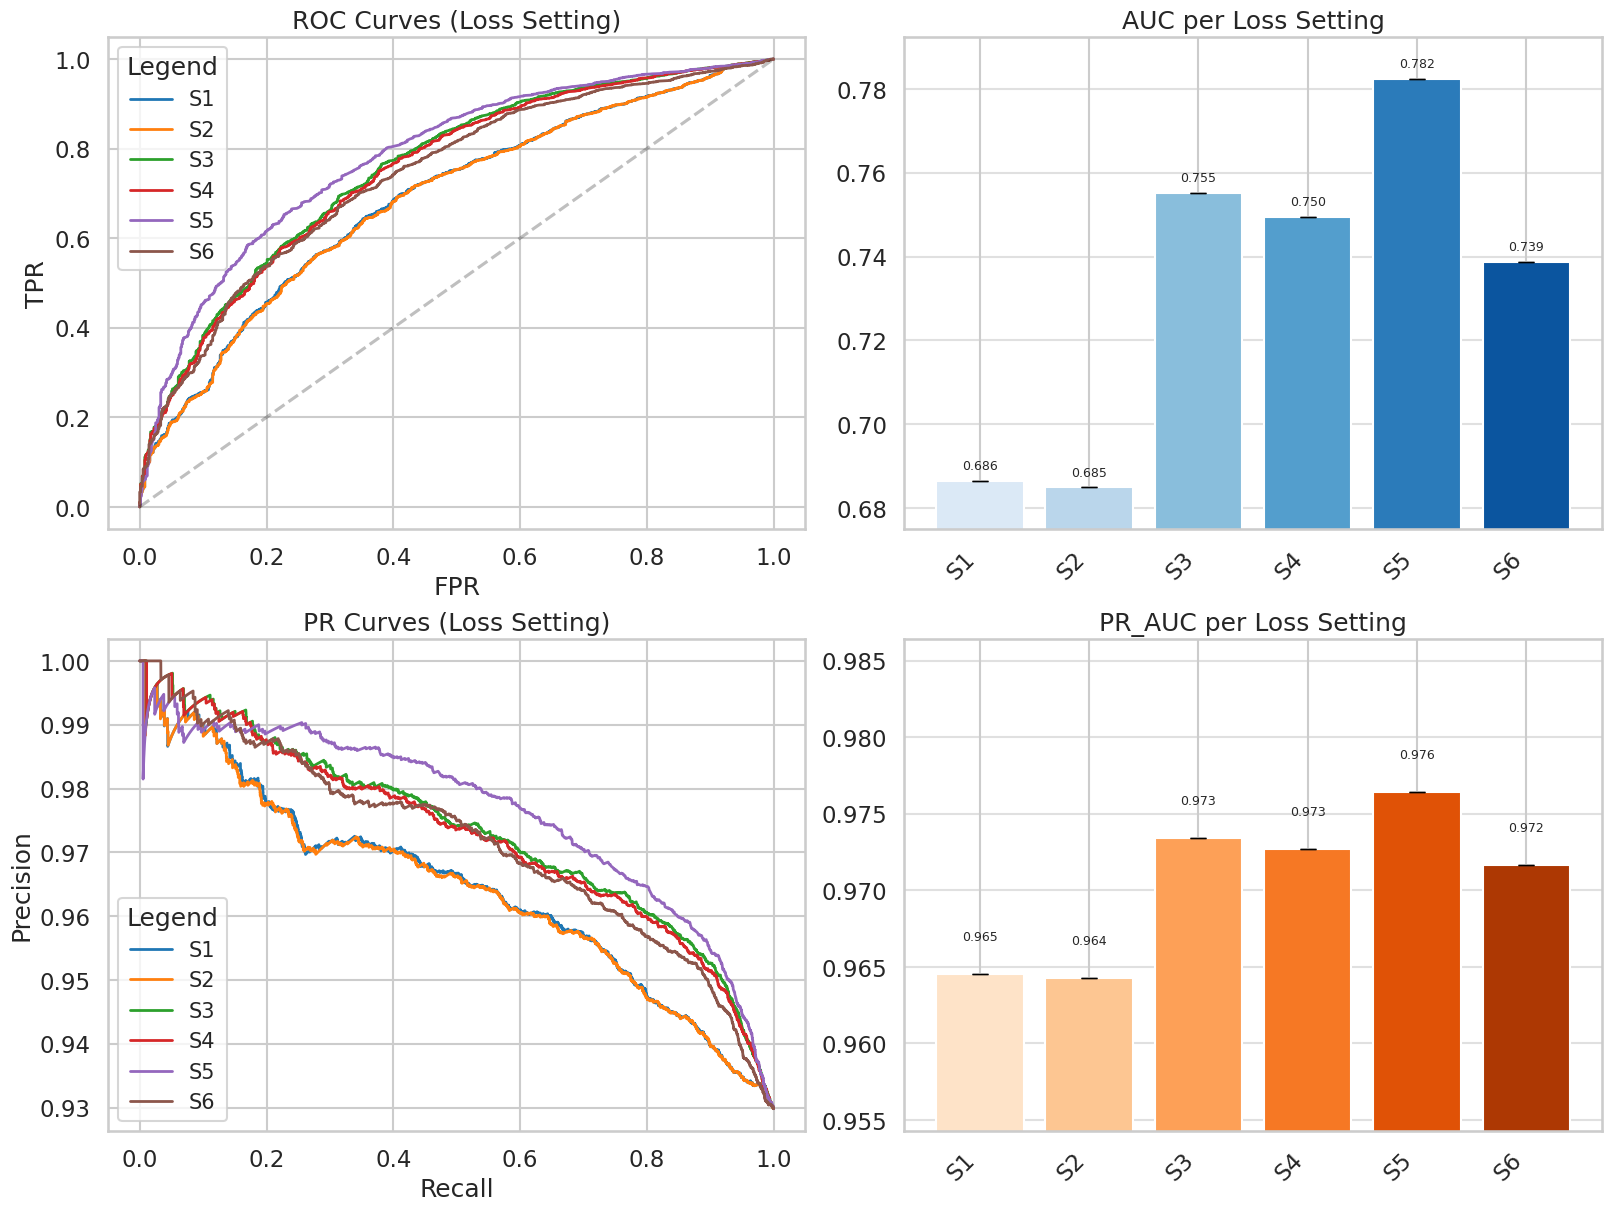

### Summary of Metrics (Loss Setting)

|    | short   | name                                                                   |   AUC_mean |   AUC_std |   PR_AUC_mean |   PR_AUC_std |
|---:|:--------|:-----------------------------------------------------------------------|-----------:|----------:|--------------:|-------------:|
|  0 | S1      | BCEWithLogitsLoss|mult=1|ups=True|only_sampled=False|reps=1            |   0.686494 |         0 |      0.96456  |            0 |
|  1 | S2      | BCEWithLogitsLoss|mult=1|ups=True|only_sampled=True|reps=1             |   0.684963 |         0 |      0.96428  |            0 |
|  2 | S3      | WeightedBCEWithLogitsLoss|mult=0.5|ups=True|only_sampled=False|reps=1  |   0.755235 |         0 |      0.973413 |            0 |
|  3 | S4      | WeightedBCEWithLogitsLoss|mult=0.5|ups=True|only_sampled=True|reps=1   |   0.74951  |         0 |      0.972702 |            0 |
|  4 | S5      | WeightedBCEWithLogitsLoss|mult=0.5|ups=False|only_sampled=False|reps=1 |   0.782446 |         0 |      0.976445 |            0 |
|  5 | S6      | WeightedBCEWithLogitsLoss|mult=0.5|ups=False|only_sampled=True|reps=1  |   0.738674 |         0 |      0.971664 |            0 |

In [18]:
# Generate plots and metrics output for the Loss Settings
plot_experiment_results(settings_results, title_suffix="Loss Setting", filename="report_grid.png")

Outcome:

- Switchting from BCE to Weighted improves performance with a near optimal factor of pos_loss_multiplier = 0.5

- using the true observed negative labels as learning signal improves performance to the pendent where this nubmer is sampled.
- The setting where only the true observed negatives are used and the class imbalance is tackled via the weighted loss function performs clearly the best. this indicates that the true negatives indeed deliver a stronger learning signal.


## Experiment of Embeddings

In [29]:
feature_settings = [{
    "feature": "__ONES__",
},
{
    "feature": "DESC_GPT",
},
]

In [30]:
feature_results = []
for i, setting in enumerate(feature_settings):
    feature = setting.get('feature')
    # Use the isolated config definition for feature evaluation
    config_feature = get_feature_experiment_config()
    config_feature.graph.feature = feature
    
    name = f"Feature|{feature}"
    print(f"=== Running [{i+1}/{len(feature_settings)}]: {name} ===")

    run = main(config_feature)
    y_true, y_scores = np.asarray(run['label']), np.asarray(run['test_scores'])
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    feature_results.append({"name": name, "metrics": run["metrics"], "precision": precision, "recall": recall, "fpr": fpr, "tpr": tpr})

2026-04-20 17:16:10,129 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI
2026-04-20 17:16:10,322 - DEBUG - Final graph has 1539 nodes and 54892 edges.
Positive edges: 51108, 
Negative edges: 3784
2026-04-20 17:16:10,323 - DEBUG - Run 1/1 for __ONES__ | LR: 0.0003


=== Running [1/2]: Feature|__ONES__ ===
======== __ONES__ ========


2026-04-20 17:16:10,345 - DEBUG - Using imbalanced loss with pos_weight: 0.0370
2026-04-20 17:16:36,407 - DEBUG - Early stopping at epoch 17
2026-04-20 17:16:37,154 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE __ONES__ -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.6597
PR_AUC: 0.9611
=== Running [2/2]: Feature|DESC_GPT ===


2026-04-20 17:16:39,938 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-20 17:16:40,011 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-20 17:16:40,013 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-04-20 17:16:40,043 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-04-20 17:17:14,459 - DEBUG - Early stopping at epoch 26


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764


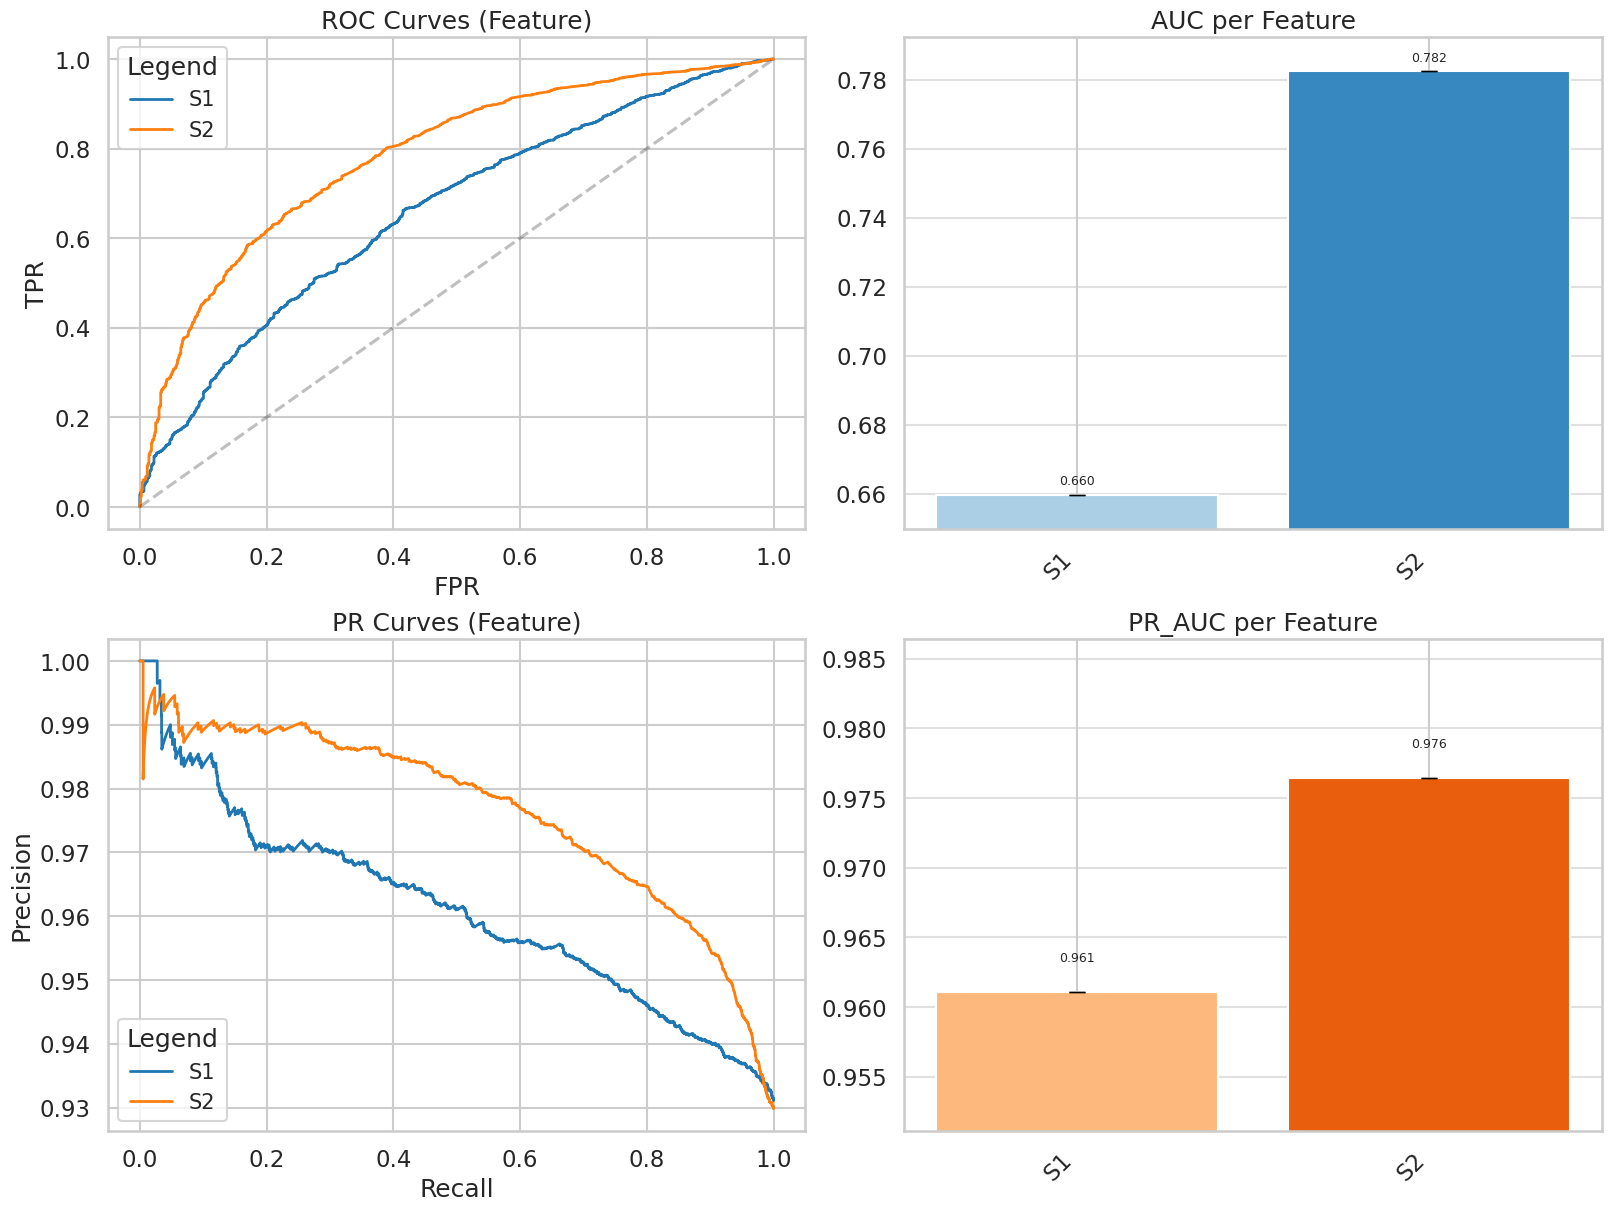

### Summary of Metrics (Feature)

|    | short   | name             |   AUC_mean |   AUC_std |   PR_AUC_mean |   PR_AUC_std |
|---:|:--------|:-----------------|-----------:|----------:|--------------:|-------------:|
|  0 | S1      | Feature|__ONES__ |   0.659729 |         0 |      0.961097 |            0 |
|  1 | S2      | Feature|DESC_GPT |   0.782446 |         0 |      0.976445 |            0 |

In [32]:
# Generate plots and metrics output for the Embeddings Settings
plot_experiment_results(feature_results, title_suffix="Feature", filename="report_grid_features.png")

- Strong learning signal by using description embedding of drugs using the GPT model.

## Analysis of trained model

- analysis of drug class
- visualizations
- 

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [37]:
# config 3 definition: uses the features config explicitly configured with DESC_GPT
config_analysis = get_feature_experiment_config()
config_analysis.graph.feature = "DESC_GPT"

In [38]:
config_analysis

Config(graph=GraphParams(current_graph='DrugBank_CRESCENDDI', feature='DESC_GPT', col_name_drug_id='Drug ID', seed_graph_sampling=42, available_graphs={'DrugBank': '/data/giobbi/GRAPH/drugbank_graph.csv', 'positive_edges_CRESCENDDI': '/data/giobbi/CRESCENDDI/positive_edges_CRESCENDDI.csv', 'CRESCENDDI': '/data/giobbi/CRESCENDDI/CRESCENDDI_wo_contradiction.csv', 'DrugBank_CRESCENDDI': '/data/giobbi/GRAPH/drugbank_crescenddi_graph_wo_contradiction.csv', 'ogbl-ddi': '/data/giobbi'}), training=TrainingParams(learning_rate=0.0003, epochs=100, patience=10, lr_lambda=0.96, repetitions=1, seed=42), run=RunSettings(take_negative_samples=True, balanced_labels=False, upsample_negative_labels=False, use_only_sampled_negatives_in_train=False, loss_type=<LossType.WeightedBCEWithLogitsLoss: 'WeightedBCEWithLogitsLoss'>, pos_loss_multiplier=0.5, focal_loss_gamma=2.0))

In [39]:
from sklearn.manifold import TSNE
from sklearn.metrics import precision_recall_curve

# Run the model using the analysis config
run = main(config_analysis)

# Unpack run results
test_data, test_scores, data, model = run["test_data"], run["test_scores"], run["data"], run["model"]
node_id_map = run["node_id_map"]
reversed_node_id_map = {v: k for k, v in node_id_map.items()}

2026-04-20 18:52:13,677 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI
2026-04-20 18:52:16,593 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-20 18:52:16,665 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-20 18:52:16,668 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-04-20 18:52:16,696 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-04-20 18:52:48,824 - DEBUG - Early stopping at epoch 26


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764


In [40]:
# Compute threshold and mapped predictions
threshold = find_balanced_threshold(test_scores)
gt, pred = test_data.edge_label.cpu().numpy().astype(int), (test_scores >= threshold).astype(int)

# Fast vectorized node lookups for edges
src_idx, tgt_idx = test_data.edge_label_index.cpu().numpy()
sources, targets = np.vectorize(reversed_node_id_map.get)(src_idx), np.vectorize(reversed_node_id_map.get)(tgt_idx)

# Classification mapping
pred_classes = np.where(gt == 1, np.where(pred == 1, 'TP', 'FN'), np.where(pred == 1, 'FP', 'TN'))

# Create dataframe mapping each source and target to their prediction classes
cols = {"source": np.concatenate([sources, targets]), 
        "target": np.concatenate([targets, sources]), 
        "pred_class": np.tile(pred_classes, 2)}
edges_df = pd.DataFrame(cols)

# Aggregate classification counts across all connected edges per source
node_info_trained = pd.get_dummies(edges_df['pred_class']).groupby(edges_df['source']).sum()[['TP', 'TN', 'FP', 'FN']]
c = node_info_trained.sum(axis=1)

node_info_trained = node_info_trained.assign(
    count=c,
    perc_missclassified=(node_info_trained['FP'] + node_info_trained['FN']) / c * 100,
    perc_neg_gt=(node_info_trained['FP'] + node_info_trained['TN']) / c * 100,
    balanced_error_rate=0.5 * (
        node_info_trained['FP'] / (node_info_trained['FP'] + node_info_trained['TN'] + 1e-10) +
        node_info_trained['FN'] / (node_info_trained['TP'] + node_info_trained['FN'] + 1e-10)
    )
)

print(f"Threshold: {threshold:.4f} | Negatives: {node_info_trained['FN'].sum() + node_info_trained['TN'].sum()}")
display(node_info_trained.head())

Threshold: 0.5001 | Negatives: 10760


,TP,TN,FP,FN,count,perc_missclassified,perc_neg_gt,balanced_error_rate
source,,,,,,,,
DB00005,3,0,0,0,3,0.0000,0.0000,0.0000
DB00006,0,0,0,6,6,100.0000,0.0000,0.5000
DB00007,29,0,0,11,40,27.5000,0.0000,0.1375
DB00008,1,0,0,2,3,66.6667,0.0000,0.3333
DB00009,0,3,0,21,24,87.5000,12.5000,0.5000


### Additional Features

In [41]:
# 1. Latent Space Embeddings (t-SNE)
model.eval()
with torch.no_grad():
    node_embeddings = model.encode(data.x, data.edge_index).cpu().numpy()
    
tsne = TSNE(n_components=2)
latent_tsne = pd.DataFrame(tsne.fit_transform(node_embeddings), columns=["TSNE-1_latent", "TSNE-2_latent"])
latent_tsne.index = pd.Series(latent_tsne.index).map(lambda x: reversed_node_id_map.get(int(x), f"unknown_{int(x)}"))

# 2. Original GPT Embeddings (t-SNE)
original_df = pd.read_csv("/data/giobbi/embeddings/DESC_GPT.csv", sep="\t", index_col=0)
original_df.set_index(original_df.columns[0], inplace=True)

original_tsne = pd.DataFrame(tsne.fit_transform(original_df.select_dtypes("number").dropna()), 
                             index=original_df.index, columns=["TSNE-1_input", "TSNE-2_input"])

# 3. Load ATC Classes & Join
atc_features = pd.read_csv("/data/giobbi/embeddings/not_aligned_with_model/drug_description_enriched_atc.csv", sep="\t", index_col=0)
atc_features['atc_class_lvl_1'] = atc_features['atc_class_lvl_1'].str.split(': ').str[-1]

# Consolidate into single embedding DataFrame (Use inner join to match original behavior and drop unrelated drugs)
embedding = original_tsne.join(latent_tsne, how='inner') \
    .join(atc_features.set_index("Drug ID"), how="left") \
    .join(node_info_trained[["perc_missclassified", "balanced_error_rate", "count", "perc_neg_gt"]].rename(columns={"count": "edge_count"}), how="left")

embedding['pharma_class'], class_mapping = pd.factorize(embedding['atc_class_lvl_1'].fillna("Unknown"))
display(embedding.head(3))

,TSNE-1_input,TSNE-2_input,TSNE-1_latent,TSNE-2_latent,Drug Name,Discription,Description_Masked,drug_unique_count,drug_count,pharma_class,drug_name,atc_match,atc_class_lvl_1,perc_missclassified,balanced_error_rate,edge_count,perc_neg_gt
DB00005,25.9368,-42.2882,-10.7411,-25.6795,Etanercept,Dimeric fusion protein consisting of the extra...,Dimeric fusion protein consisting of the extra...,2,3,0,etanercept,Etanercept,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,0.0000,0.0000,3.0000,0.0000
DB00006,0.2889,-38.6974,7.0675,-37.9638,Bivalirudin,Bivalirudin is a synthetic 20 residue peptide ...,<DRUG> is a synthetic 20 residue peptide (<DRU...,2,4,1,bivalirudin,Bivalirudin,BLOOD AND BLOOD FORMING ORGAN DRUGS,100.0000,0.5000,6.0000,0.0000
DB00007,49.9445,46.7840,35.1130,29.9472,Leuprolide,Leuprolide is a synthetic 9-residue peptide an...,<DRUG> is a synthetic 9-residue peptide analog...,1,4,2,leuprolide,NaN,NaN,27.5000,0.1375,40.0000,0.0000


,class,n,median,IQR,mean,std
9,NERVOUS SYSTEM DRUGS,248,29.4093,38.3356,38.5599,32.9028
2,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,177,64.7059,66.6667,64.2071,34.2902
13,Unknown,176,90.2778,66.6667,67.2695,38.4224
0,ALIMENTARY TRACT AND METABOLISM DRUGS,163,82.7586,57.7381,68.8032,33.6697
5,CARDIOVASCULAR SYSTEM DRUGS,162,61.8056,63.9388,60.6399,31.5134
1,ANTIINFECTIVES FOR SYSTEMIC USE,152,88.8889,58.7500,71.8585,33.0236
11,SENSORY ORGAN DRUGS,115,71.4286,58.2011,64.3044,32.8076
10,RESPIRATORY SYSTEM DRUGS,104,21.5251,62.7493,36.5128,36.8971
6,DERMATOLOGICALS,90,66.6667,66.2162,64.7818,34.1525
7,GENITO URINARY SYSTEM AND SEX HORMONES,79,85.7143,57.7778,71.0995,31.8836


2026-04-20 18:53:11,636 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7c38bdd57df0>


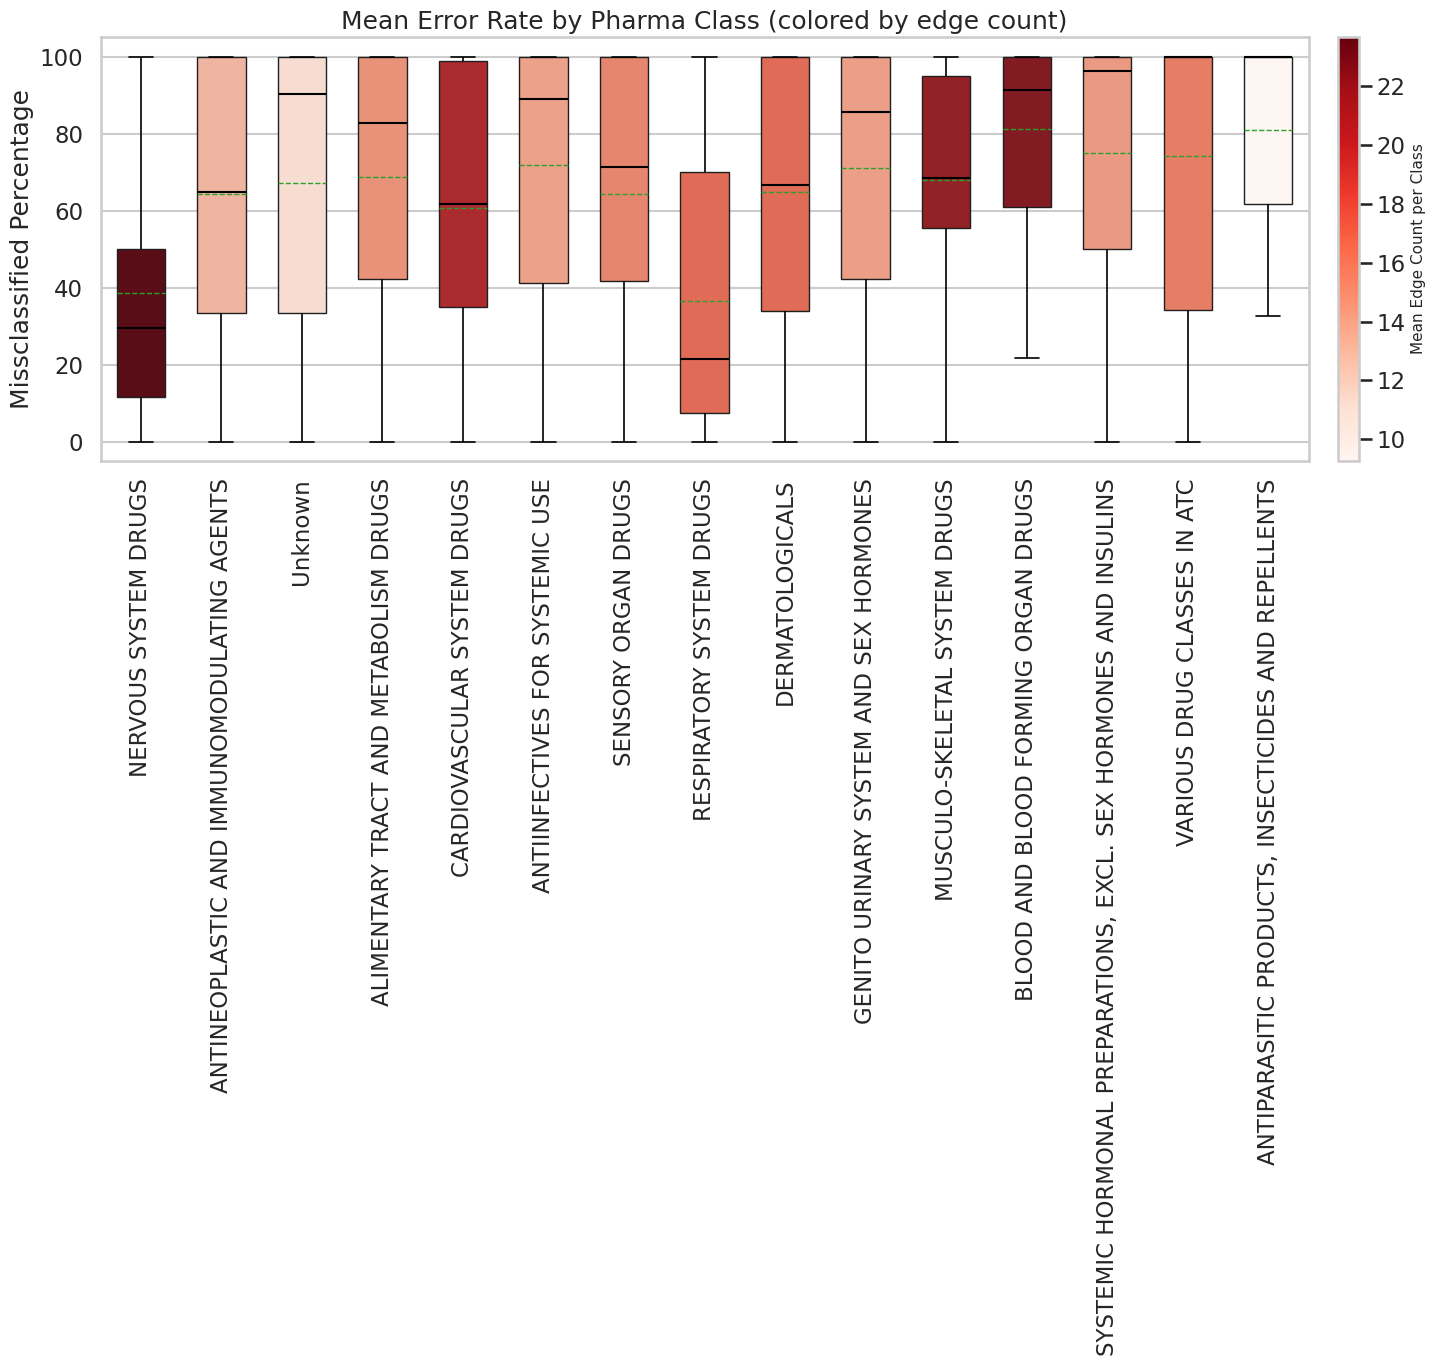

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare clean dataframe for analysis (only keep nodes with actual test predictions)
df = embedding.dropna(subset=['perc_missclassified']).reset_index(drop=True).assign(class_=lambda x: x['atc_class_lvl_1'].fillna('Unknown'))

# Generate descriptive statistics in one pass
summary_df = df.groupby('class_')['perc_missclassified'].agg(
    n='count', median='median', IQR=lambda x: x.quantile(0.75) - x.quantile(0.25), mean='mean', std='std'
).dropna().reset_index().rename(columns={'class_': 'class'}).sort_values('n', ascending=False)

display(summary_df.head(20))
summary_df.to_csv('pharma_class_summary_all.csv', index=False)

# Visualization setup
sns.set_style('whitegrid')
order = summary_df['class'].tolist()
edge_counts = df.groupby('class_')['edge_count'].mean().reindex(order)

# Map edge counts to colors using Matplotlib's builtin normalize
norm = plt.Normalize(edge_counts.min(), edge_counts.max())
cmap = plt.cm.Reds
palette = {c: cmap(norm(v)) for c, v in edge_counts.items()}

# Create plot (increased vertical figure size to fix squishing)
fig, ax = plt.subplots(figsize=(16, 14))
sns.boxplot(
    data=df[df['class_'].isin(order)], x='class_', y='perc_missclassified', order=order,
    width=0.6, showcaps=True, showfliers=False, palette=palette, 
    showmeans=True, meanline=True, ax=ax,
    medianprops={'linewidth': 1.5, 'color': 'black'},
    whiskerprops={'linewidth': 1.2, 'color': 'black'},
    capprops={'linewidth': 1.2, 'color': 'black'},
)

ax.tick_params(axis='x', rotation=90)
ax.set(title='Mean Error Rate by Pharma Class (colored by edge count)', xlabel='', ylabel='Missclassified Percentage')

# Colorbar
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.02).set_label('Mean Edge Count per Class', fontsize=11)

plt.tight_layout()
plt.savefig('pharma_class_all_categories.png', dpi=200, bbox_inches='tight')
plt.show()

Black line: median
Green line: mean

### Pharma-class analysis — Interpretation and implications

- **Practical / scientific implications:**

  - The model's `balanced_error_rate` is heterogeneous across `atc_class_lvl_1` categories: some classes are consistently easier or harder for the model.
  - The effect size (~10%) is modest — class membership explains part of the variance but there remains substantial overlap between distributions.

- **Possible causes to investigate:**

  - Data imbalance: uneven sample counts give larger classes more training signal.
  - Domain / feature gaps: classes may differ in chemical diversity or representation in feature space.
  - Label quality: some classes may contain noisier or ambiguous labels, increasing error rates.

- **Recommended next steps (actionable):**

  - Run per‑class diagnostics: mean `balanced_error_rate`, counts, confusion matrices, and calibration plots (see `pharma_class_summary_all.csv`).
  - Try remediation experiments: stratified sampling, class reweighting, targeted augmentation, or class‑specific models.
  - Fit a regression or mixed‑effects model including sample size and covariates to quantify class effects while controlling confounders.


### Visualizations

In [43]:
# ===== INTERACTIVE VISUALIZATION =====
render_interactive_visualization(embedding, test_data, test_scores, threshold, reversed_node_id_map)

# Discussion

# Open Points